<a href="https://colab.research.google.com/github/Ngozi-uzor/CALIFORNIA-TEST-SCORES-Complete-Statistical-Inference-Project/blob/main/Assignment1_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1

## Part a: findall(text, pattern) function

we need to find all the places where a pattern appears in a text. The function should return a list of starting positions.

The logic is to slide through the text one character at a time and check if the pattern matches at that position.

In [1]:
def findall(text, pattern):
    results = []
    n = len(text)
    m = len(pattern)

    # Check each possible starting position
    for i in range(n - m + 1):
        # Check if pattern matches at position i
        if text[i:i+m] == pattern:
            results.append(i)

    return results

Test with the examples in the assignment:

In [18]:
# Test 1: Finding 'the' in a sentence
text1 = 'Now is the time for all good men to come to the aid of their countrymen'
print("findall(text, 'the') =", findall(text1, 'the'))
# Should return [7, 44, 58]

# Test 2: Finding overlapping pattern 'haha'
text2 = 'Te hehehehe'
print("findall('Te hehehehe', 'hehe') =", findall(text2, 'hehe'))
# Returns [3, 5, 7] because 'haha' overlaps

# Test 3: Pattern not found
print("findall('Te hehehehe', 'x') =", findall(text2, 'x'))
# Returns []

findall(text, 'the') = [7, 44, 55]
findall('Te hehehehe', 'hehe') = [3, 5, 7]
findall('Te hehehehe', 'x') = []


**Time Complexity Analysis:**

Let n = len(text) and m = len(pattern).

We loop through the text about n times, and at each position we compare up to m characters. So the time complexity is **O(n × m)**.

## Partb: benchmarkFindAll() to visualize time complexity

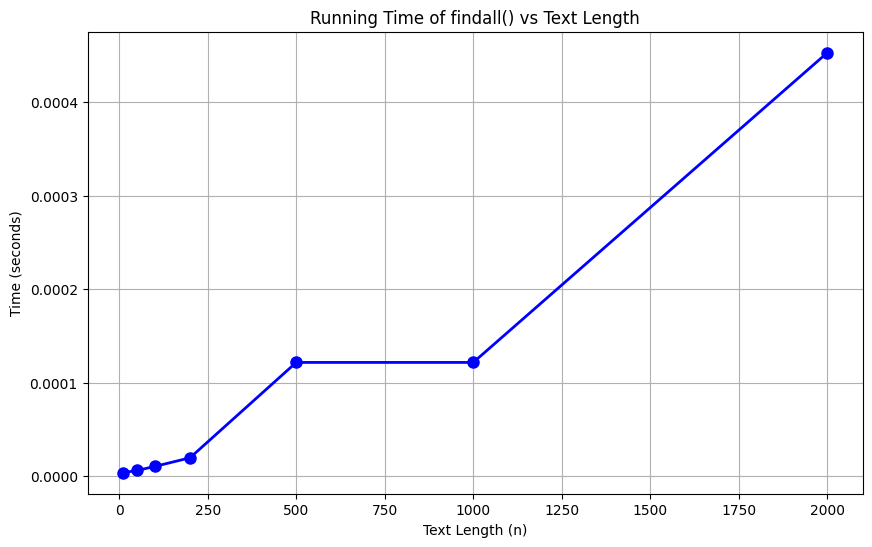

In [19]:
import matplotlib.pyplot as plt
import random
import time

def benchmarkFindAll():
    # Different text sizes to test
    n_values = [10, 50, 100, 200, 500, 1000, 2000]
    times = []

    # Fixed pattern length
    pattern_len = 5

    for n in n_values:
        # Create random text of length n
        text = ''.join(random.choices('abcdefghij', k=n))
        pattern = ''.join(random.choices('abcdefghij', k=pattern_len))

        # Measure time
        start = time.time()
        findall(text, pattern)
        end = time.time()

        times.append(end - start)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(n_values, times, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Text Length (n)')
    plt.ylabel('Time (in seconds)')
    plt.title('Running Time of findall() vs Text Length')
    plt.grid(True)
    plt.show()

benchmarkFindAll()

The graph shows that running time grows linearly with text length n.


## Part c: findallFile(inName, pattern) to search in files

In [20]:
def findallFile(inName, pattern):
    results = []
    # Open and read the file line by line
    with open(inName, 'r') as file:
        line_number = 1
        for line in file:
            # Find all pattern positions in this line
            positions = findall(line, pattern)
            # Add each position as a tuple
            for pos in positions:
                results.append((line_number, pos))
            line_number = line_number + 1

    return results

In [ ]:
# Create sample mobyDick.txt file for testing
sample_text = """Call me Ishmael. Some years ago I went to sea.
There was a great white whale that the captain hunted.
The whale was enormous and powerful.
Many sailors feared this whale.
Captain Ahab was obsessed with finding the whale."""

with open('mobyDick.txt', 'w') as f:
    f.write(sample_text)

# Find all places where 'whale' appears
results = findallFile('mobyDick.txt', 'whale')
print("Finding 'whale' in mobyDick.txt:")
print(results)

# Q2

## Part a: smooth(data, windowLength) function

In [5]:
def smooth(data, windowLength):
    result = []
    n = len(data)
    half = windowLength // 2

    for i in range(n):
        # Find window boundaries
        start = max(0, i - half)
        end = min(n, i + half + 1)

        # Calculate average of window
        window_sum = 0
        count = 0
        for j in range(start, end):
            window_sum = window_sum + data[j]
            count = count + 1

        average = window_sum / count
        result.append(average)

    return result

In [6]:
# example from assignment
data = [3, 4, 2, 4, 3, 6]
print("Data:", data)
print("smooth(data, 5) =", smooth(data, 5))

Data: [3, 4, 2, 4, 3, 6]
smooth(data, 5) = [3.0, 3.25, 3.2, 3.8, 3.75, 4.333333333333333]


**Time Complexity:** O(n × w) where n is data length and w is window length.


## Part b: benchmarkSmooth() to visualize time complexity



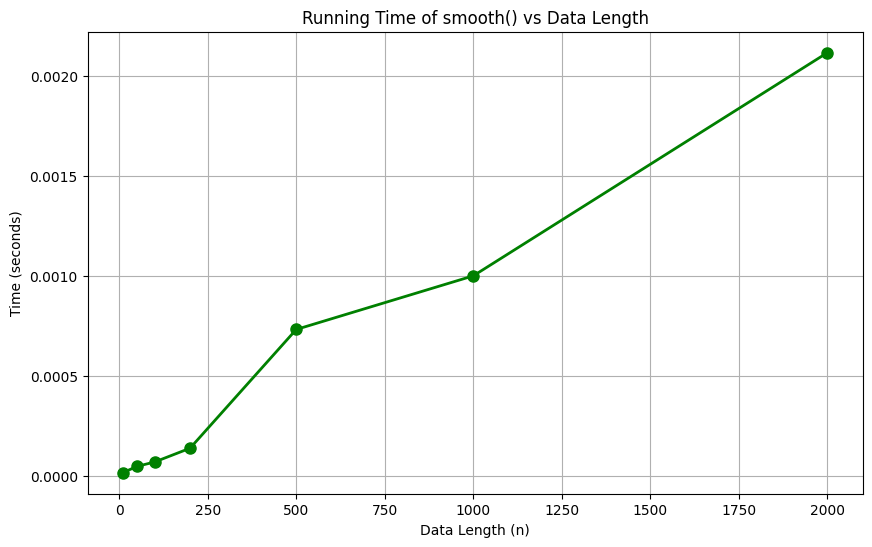

In [7]:
def benchmarkSmooth():
    n_values = [10, 50, 100, 200, 500, 1000, 2000]
    times = []
    window = 5

    for n in n_values:
        # Create random data
        data = [random.random() * 100 for _ in range(n)]

        # Measure time
        start = time.time()
        smooth(data, window)
        end = time.time()

        times.append(end - start)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(n_values, times, 'go-', linewidth=2, markersize=8)
    plt.xlabel('Data Length (n)')
    plt.ylabel('Time (seconds)')
    plt.title('Running Time of smooth() vs Data Length')
    plt.grid(True)
    plt.show()

benchmarkSmooth()

## Part c: Sorting Algorithm (implementation and the worst case analysis)

In [8]:
def sort_list(lst):
    # Base case: empty or single element list is already sorted
    if len(lst) <= 1:
        return lst

    # Pick first element as axis
    axis = lst[0]

    # Split into left and right
    left = []
    right = []

    for i in range(1, len(lst)):
        if lst[i] < axis:
            left.append(lst[i])
        else:
            right.append(lst[i])

    # Sort and combine
    sorted_left = sort_list(left)
    sorted_right = sort_list(right)

    return sorted_left + [axis] + sorted_right

### Worst Case Example

The worst case happens when the list is **already sorted** (either ascending or descending).

**Example:** `[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]`

Here's why this is bad: When we pick the first element (1) as pivot, all other elements are larger, so they all go to the right side. Then we pick 2, and again everything goes right. This keeps happening.

Instead of splitting the list in half each time (which would be fast), we only remove one element per level. So we need n levels of recursion.

In [9]:
# Demonstrating worst case
worst_case = [1, 2, 3, 4, 5]
print("Worst case input:", worst_case)
print()
print("What happens at each step:")
print("  axis=1, left=[], right=[2,3,4,5]  -> unbalanced!")
print("  axis=2, left=[], right=[3,4,5]    -> still unbalanced!")
print("  axis=3, left=[], right=[4,5]")
print("  axis=4, left=[], right=[5]")
print("  axis=5, left=[], right=[]")

Worst case input: [1, 2, 3, 4, 5]

What happens at each step:
  axis=1, left=[], right=[2,3,4,5]  -> unbalanced!
  axis=2, left=[], right=[3,4,5]    -> still unbalanced!
  axis=3, left=[], right=[4,5]
  axis=4, left=[], right=[5]
  axis=5, left=[], right=[]


### Worst Case Time Complexity: O(n²)

At each level, we do O(n) work to partition, and we have n levels because we only remove one element at a time.

Total work = n + (n-1) + (n-2) + ... + 1 = n(n+1)/2 = **O(n²)**

# Q3


## Part a: TF-IDF Calculation

**Given:**
- Total documents: 10 million
- Word 'w' appears in: 320 documents
- Maximum frequency of any word in document d: 15

We are to find the TF-IDF score when word w appears a once and b five times.

The TF-IDF formula is:
- TF = (times word appears in doc) / (max frequency in doc)
- IDF = log₁₀(total docs / docs containing word)
- TF-IDF = TF × IDF

In [10]:
import math

# Given values
total_docs = 10000000  # 10 million
docs_with_w = 320
max_freq = 15

# Calculate IDF (same for both cases)
IDF = math.log10(total_docs / docs_with_w)
print("IDF = log10(10,000,000 / 320)")
print("IDF = log10(31250)")
print(f"IDF = {IDF:.4f}")
print()

IDF = log10(10,000,000 / 320)
IDF = log10(31250)
IDF = 4.4949



In [11]:
# Part (a): Word appears ONCE
TF_once = 1 / max_freq
TF_IDF_once = TF_once * IDF

print("(a) When word appears ONCE:")
print(f"    TF = 1/15 = {TF_once:.4f}")
print(f"    TF-IDF = {TF_once:.4f} × {IDF:.4f} = {TF_IDF_once:.4f}")
print()

(a) When word appears ONCE:
    TF = 1/15 = 0.0667
    TF-IDF = 0.0667 × 4.4949 = 0.2997



In [12]:
# Part (b): Word appears FIVE times
TF_five = 5 / max_freq
TF_IDF_five = TF_five * IDF

print("(b) When word appears FIVE times:")
print(f"    TF = 5/15 = {TF_five:.4f}")
print(f"    TF-IDF = {TF_five:.4f} × {IDF:.4f} = {TF_IDF_five:.4f}")

(b) When word appears FIVE times:
    TF = 5/15 = 0.3333
    TF-IDF = 0.3333 × 4.4949 = 1.4983


**Answer:**
- (a) TF-IDF ≈ **0.30** when word appears once
- (b) TF-IDF ≈ **1.50** when word appears five times

## Part b: Hash Function Analysis

**Given:**
- Hash keys are multiples of some constant c (like 0, c, 2c, 3c, ...)
- Hash function h(x) = x mod 15

**Question:** For what values of c will h be a good hash function (distribute keys evenly into all 15 buckets)?

A hash function is good when it spreads keys evenly across all buckets. Let's check which values of c do this:

In [21]:
def check_hash_quality(c):
    buckets_used = set()

    # Check first 15 multiples of c
    for k in range(15):
        key = c * k
        bucket = key % 15
        buckets_used.add(bucket)

    return len(buckets_used)

# Test for c = 1 to 15
print("Value of c | Buckets Used | Good?")
print("-" * 35)

for c in range(1, 16):
    num_buckets = check_hash_quality(c)
    good = "YES" if num_buckets == 15 else "NO"
    print(f"    c = {c:2d}  |      {num_buckets:2d}      |  {good}")

Value of c | Buckets Used | Good?
-----------------------------------
    c =  1  |      15      |  YES
    c =  2  |      15      |  YES
    c =  3  |       5      |  NO
    c =  4  |      15      |  YES
    c =  5  |       3      |  NO
    c =  6  |       5      |  NO
    c =  7  |      15      |  YES
    c =  8  |      15      |  YES
    c =  9  |       5      |  NO
    c = 10  |       3      |  NO
    c = 11  |      15      |  YES
    c = 12  |       5      |  NO
    c = 13  |      15      |  YES
    c = 14  |      15      |  YES
    c = 15  |       1      |  NO


**Pattern:** The hash function is good when c and 15 share no common factors (except 1).

Since 15 = 3 × 5, bad values of c are those divisible by 3 or 5.

**Answer:** c will give a good hash function when **gcd(c, 15) = 1**

Good values: c = 1, 2, 4, 7, 8, 11, 13, 14, ...  
Bad values: c = 3, 5, 6, 9, 10, 12, 15, ...

# Q4

## Part a: Find the Largest Integer

**Mapper:** For each integer, emit ("max", integer)  
**Reducer:** Take maximum of all values with key "max"

In [14]:
def mapper_max(integer):
    # Emit with constant key so all go to same reducer
    return ("max", integer)

def reducer_max(key, values):
    # Return the maximum value
    return (key, max(values))

## Part b: Find the Average of All Integers

**Mapper:** For each integer x, emit ("avg", (x, 1))  
**Reducer:** Sum all values and counts, then divide

In [15]:
def mapper_avg(integer):
    # Emit (sum, count) pair
    return ("avg", (integer, 1))

def reducer_avg(key, values):
    # Sum up all values and counts
    total = 0
    count = 0
    for val, cnt in values:
        total = total + val
        count = count + cnt
    average = total / count
    return (key, average)

## Part c: Get Unique Integers (Each Appearing Only Once)

**Mapper:** For each integer x, emit (x, 1)  
**Reducer:** For each key, just output the key (ignore values)

In [16]:
def mapper_unique(integer):
    # Use integer itself as key
    return (integer, 1)

def reducer_unique(key, values):
    # Just return the key (the unique integer)
    return key

## Part d: Count of Distinct Integers

Similar to part (c), but we count the unique keys.

**Mapper 1:** For each integer x, emit (x, 1)  
**Reducer 1:** For each key, emit ("count", 1)  
**Reducer 2:** Sum all the 1s

In [17]:
# Example with duplicates
data = [5, 3, 8, 3, 5, 9, 8, 5, 2]
print("Input:", data)

# First MapReduce: get unique keys
unique_keys = set(data)  # This is what the first MapReduce does
print("Unique values:", unique_keys)

# Second MapReduce: count them
# Map: each unique key emits ("count", 1)
# Reduce: sum all the 1s
count = len(unique_keys)
print("Count of distinct integers:", count)

Input: [5, 3, 8, 3, 5, 9, 8, 5, 2]
Unique values: {2, 3, 5, 8, 9}
Count of distinct integers: 5
